# GGMP — 1D Distributional Regression Demo

This notebook demonstrates the **Gaussian GP for Gaussian Mixture data (GGMP)** model on a synthetic 1D example.

Each "observation" at an input location $x$ is not a scalar but an entire probability distribution — represented here as a (domain, density) pair.  The true generating process is a two-component Gaussian mixture whose means vary smoothly with $x$:

$$p(y \mid x) = w_1 \, \mathcal{N}\!\left(y \mid \mu_1(x),\, \sigma_1^2\right) + w_2 \, \mathcal{N}\!\left(y \mid \mu_2(x),\, \sigma_2^2\right)$$

with
$\mu_1(x) = 2 \sin(2\pi x)$ and $\mu_2(x) = -1.5 \cos(\pi x)$.

The GGMP workflow:
1. Represent each observed PDF as a K-component GMM
2. Place one independent GP over the component means across stations
3. Optimize GP hyperparameters (marginal likelihood)
4. Optimize mixture weights (EM on the density objective)
5. Predict the full distribution at new locations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import norm

from fvgp import ggmp as ggmp_module
from fvgp.ggmp import GGMP, hyperparameters

rng = np.random.default_rng(42)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
BLUE, ORANGE, GREEN, RED = "#3A86FF", "#FF6B35", "#2EC4B6", "#E63946"

## 1. Synthetic data

We place **14 training stations** at equally-spaced locations in $[0.05, 0.95]$. At each station we evaluate the true two-component GMM on a fine grid to produce an observed density curve. This mimics a setting where one has many empirical samples per station that have been converted to a smooth density estimate.

In [2]:
# ── True generating process ───────────────────────────────────────────────────
K = 2
w_true  = np.array([0.45, 0.55])
sigma1, sigma2 = 0.28, 0.22

# np.squeeze ensures scalar input → 0-D output (NumPy 2.0 compatible)
def mu1(x): return np.squeeze(2.0  * np.sin(2 * np.pi * np.asarray(x, dtype=float).ravel()))
def mu2(x): return np.squeeze(-1.5 * np.cos(np.pi     * np.asarray(x, dtype=float).ravel()))

# ── Training stations ─────────────────────────────────────────────────────────
N_train = 14
x_train = np.linspace(0.05, 0.95, N_train).reshape(-1, 1)

domain = np.linspace(-5.0, 5.0, 300)

y_data = []
for xi in x_train[:, 0]:          # iterate as scalars
    m1 = float(mu1(xi))           # mu1 returns 0-D array → float() is fine
    m2 = float(mu2(xi))
    dens = (w_true[0] * norm.pdf(domain, m1, sigma1) +
            w_true[1] * norm.pdf(domain, m2, sigma2))
    # Add a tiny amount of noise so the density is not perfectly analytical
    dens = np.maximum(dens + rng.normal(0, 2e-3, domain.shape), 0.0)
    y_data.append((domain.copy(), dens))

# ── Fine prediction grid ──────────────────────────────────────────────────────
N_pred = 120
x_pred = np.linspace(0.0, 1.0, N_pred).reshape(-1, 1)

### Plot: observed distributional data

Each row in the ridge plot below is one station.  The density curves are **non-Gaussian** and bimodal in regions where the two component means are well separated.

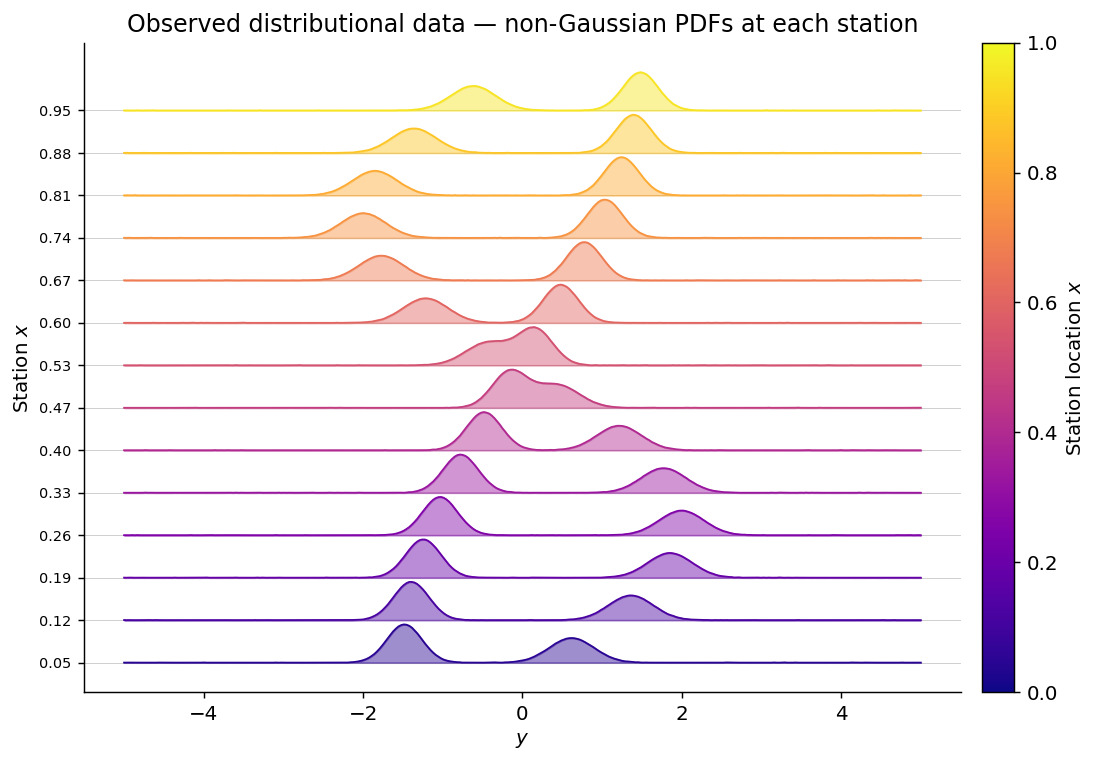

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))

cmap   = plt.cm.plasma
vmin, vmax = 0.0, 1.0
offset_scale = 1.5   # vertical spacing between ridges

for i, (xi, (dom, dens)) in enumerate(zip(x_train[:, 0], y_data)):
    offset = i * offset_scale
    norm_dens = dens / (dens.max() + 1e-12) * offset_scale * 0.9
    color = cmap((xi - vmin) / (vmax - vmin))

    ax.fill_between(dom, offset, offset + norm_dens, alpha=0.45, color=color)
    ax.plot(dom, offset + norm_dens, lw=1.0, color=color)
    ax.axhline(offset, color="#cccccc", lw=0.5, zorder=0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin, vmax))
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, pad=0.02)
cb.set_label("Station location $x$")

ax.set_xlabel("$y$")
ax.set_ylabel("Station index (offset)")
ax.set_yticks(np.arange(N_train) * offset_scale)
ax.set_yticklabels([f"{xi:.2f}" for xi in x_train[:, 0]], fontsize=8)
ax.set_ylabel("Station $x$")
ax.set_title("Observed distributional data — non-Gaussian PDFs at each station")
plt.tight_layout()
plt.show()

## 2. Build the GGMP model

We set up $K = 2$ component GPs.  Each GP is a standard squared-exponential / Matérn GP with three hyperparameters: signal variance, length scale, and a trainable constant mean.  The `hyperparameters` object bundles K sets of GP hyperparameters together with the K mixture weights and their optimization bounds.

In [4]:
# ── Hyperparameter setup ──────────────────────────────────────────────────────
# 3 params per GP: [signal_var, length_scale, mean_constant]
hps_init  = [np.array([1.0, 0.3, 0.0])] * K
hps_bounds = [np.array([[0.05, 5.0],
                         [0.02, 1.5],
                         [-5.0, 5.0]])] * K

weights_init   = np.ones(K) / K
weights_bounds = np.array([[0.01, 1.0]] * K)

hps_obj = hyperparameters(weights_init, weights_bounds, hps_init, hps_bounds)

# ── Construct GGMP ────────────────────────────────────────────────────────────
g = GGMP(x_train, y_data, hps_obj=hps_obj, likelihood_terms=K)
g.initLikelihoods()
g.initGPs()

print(f"Initialized {K} component GPs over {N_train} stations.")
for k in range(K):
    print(f"  Component {k+1}: hps = {g.gps[k].hyperparameters}")

[initGPs] Synced hps_obj: mean values = [-0.9998563682420899, 1.00014363175791]
Initialized 2 component GPs over 14 stations.
  Component 1: hps = [ 1.          0.3        -0.99985637]
  Component 2: hps = [1.         0.3        1.00014363]


## 3. Train

`train()` runs in two phases:

- **Phase 1**: maximize the marginal log-likelihood of each component GP independently (L-BFGS-B).
- **Phase 2**: run EM on the density objective to optimize the K mixture weights.

In [14]:
synced_hps = g.train(
    method="global",
    max_iter=2000,
    train_weights=True,
    weight_method="density",
    weight_max_iter=3000,
)

learned_weights = np.array([g.likelihoods[k].weight for k in range(K)])
print("\nTrained hyperparameters:")
for k, hps in enumerate(synced_hps):
    print(f"  Component {k+1}: signal_var={hps[0]:.3f}  length_scale={hps[1]:.3f}  mean={hps[2]:.3f}")
print(f"\nLearned weights: {learned_weights}  (true: {w_true})")


Trained hyperparameters:
  Component 1: signal_var=0.050  length_scale=1.496  mean=-1.000
  Component 2: signal_var=0.050  length_scale=1.473  mean=1.000

Learned weights: [0.50081995 0.49918005]  (true: [0.45 0.55])


/home/marcus/Coding/fvGP/fvgp/gp.py:677: UserWarning: Your init_hyperparameters are out of bounds. They will be over-written
  warnings.warn("Your init_hyperparameters are out of bounds. They will be over-written")


## 4. Posterior predictions

We evaluate the posterior at `x_pred`, a fine grid over $[0, 1]$.  For each prediction point we compute:

- the **mixture mean** $\mu(x^*) = \sum_k w_k\, \mu_k(x^*)$
- the **mixture variance** via the law of total variance
- the **full predictive density** $p(y^* \mid x^*) = \sum_k w_k\, \mathcal{N}(y^* \mid \mu_k(x^*),\, \nu_k(x^*) + \bar{s}_k^2)$

In [15]:
# ── Mixture mean and variance ─────────────────────────────────────────────────
mix_mean = g.posterior_mean(x_pred)        # (N_pred,)
mix_var  = g.posterior_variance(x_pred)    # (N_pred,)
mix_std  = np.sqrt(np.maximum(mix_var, 0))

# ── Per-component GP posterior mean / variance ────────────────────────────────
comp_means = np.stack(
    [g.gps[k].posterior_mean(x_pred)["m(x)"] for k in range(K)], axis=0
)  # (K, N_pred)

comp_vars = np.stack(
    [g.gps[k].posterior_covariance(x_pred, variance_only=True)["v(x)"] for k in range(K)], axis=0
)  # (K, N_pred)
mean_noise = np.array([np.mean(g.likelihoods[k].variance) for k in range(K)])
comp_stds  = np.sqrt(np.maximum(comp_vars + mean_noise[:, None], 0))  # (K, N_pred)

# ── Full predictive density on a y-grid ──────────────────────────────────────
y_grid = np.linspace(-5.0, 5.0, 400)
w_norm = learned_weights / learned_weights.sum()

# pred_density[i, j] = p(y_grid[j] | x_pred[i])
pred_density = np.zeros((N_pred, len(y_grid)))
for k in range(K):
    for i in range(N_pred):
        pred_density[i] += w_norm[k] * norm.pdf(
            y_grid, loc=comp_means[k, i], scale=comp_stds[k, i]
        )

print("Prediction complete.")

Prediction complete.


### Plot: component GP posteriors

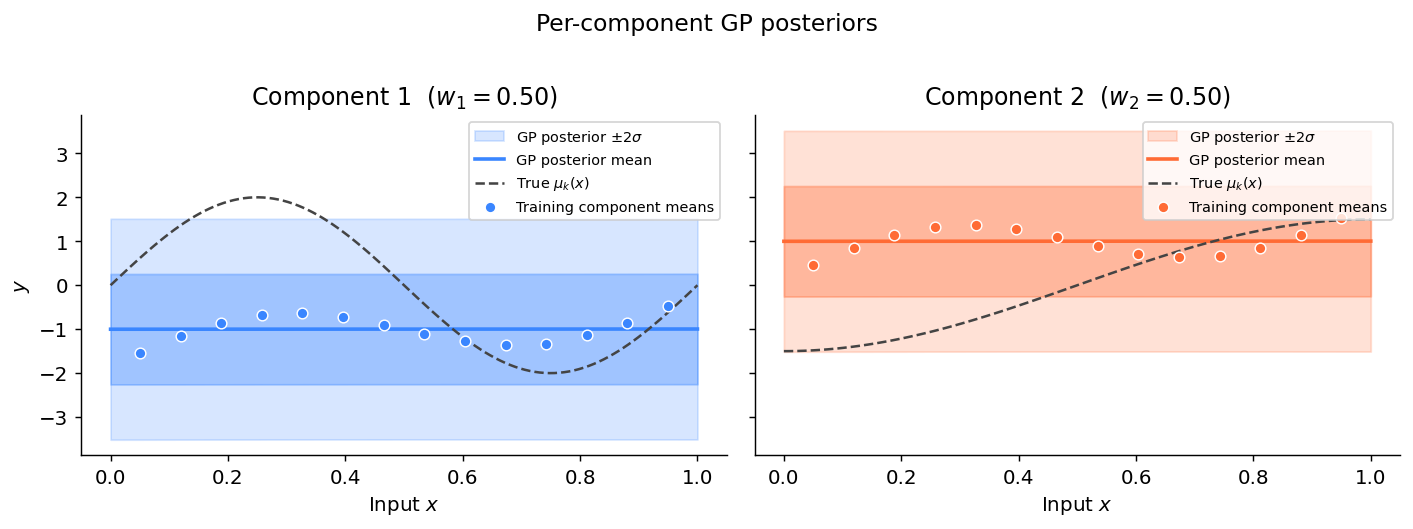

In [16]:
colors_k = [BLUE, ORANGE]
x_plot   = x_pred[:, 0]
x_train_plot = x_train[:, 0]

fig, axes = plt.subplots(1, K, figsize=(11, 4), sharey=True)

for k, ax in enumerate(axes):
    mu_k  = comp_means[k]
    std_k = comp_stds[k]
    c = colors_k[k]

    ax.fill_between(x_plot, mu_k - 2*std_k, mu_k + 2*std_k,
                    alpha=0.20, color=c, label=r"GP posterior $\pm 2\sigma$")
    ax.fill_between(x_plot, mu_k - std_k, mu_k + std_k,
                    alpha=0.35, color=c)
    ax.plot(x_plot, mu_k, color=c, lw=2, label="GP posterior mean")

    # True component mean for comparison
    true_mu = mu1(x_pred) if k == 0 else mu2(x_pred)
    ax.plot(x_plot, true_mu, "--", color="#444444", lw=1.4,
            label="True $\\mu_k(x)$")

    # Training data component means from likelihoods
    train_comp_means = g.likelihoods[k].mean
    ax.scatter(x_train_plot, train_comp_means, s=35, color=c,
               edgecolors="white", linewidths=0.8, zorder=5,
               label="Training component means")

    ax.set_xlabel("Input $x$")
    ax.set_ylabel("$y$" if k == 0 else "")
    ax.set_title(f"Component {k+1}  ($w_{k+1} = {w_norm[k]:.2f}$)")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Per-component GP posteriors", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Plot: full predictive density

The heat map shows $p(y^* \mid x^*)$ across the prediction grid.  Training station densities are overlaid as white contour lines.  The mixture mean $\pm 2\sigma$ is shown in red.

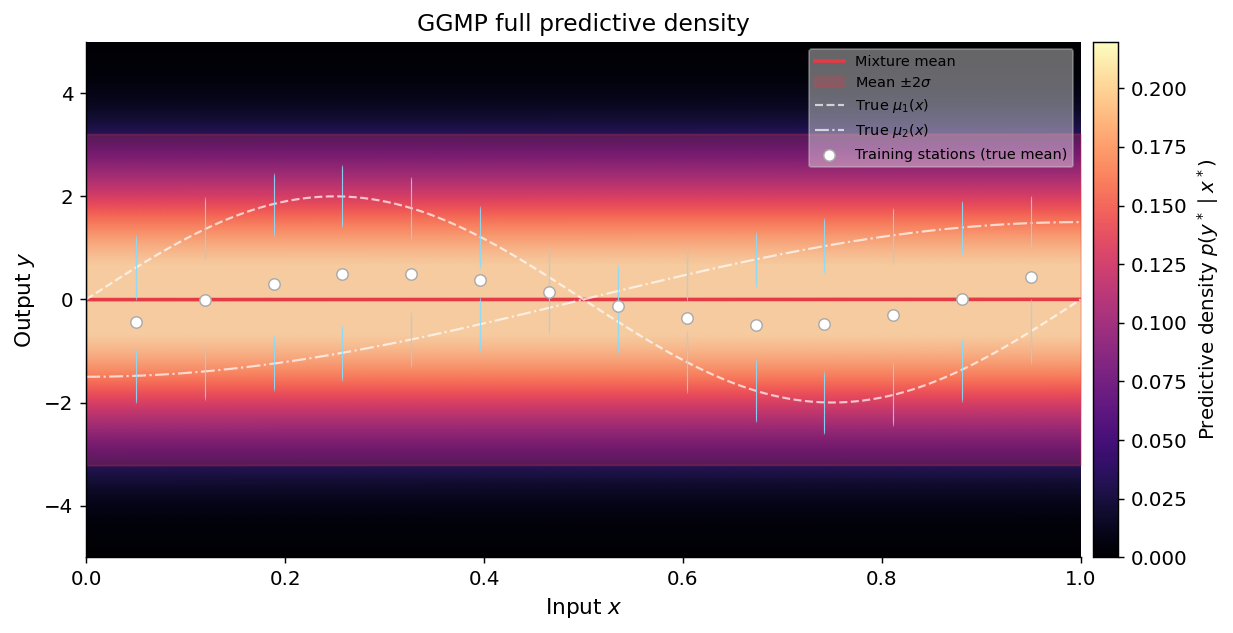

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

# ── 2D density heat map ───────────────────────────────────────────────────────
pcm = ax.pcolormesh(
    x_pred[:, 0], y_grid, pred_density.T,
    cmap="magma", shading="gouraud",
    vmin=0, vmax=pred_density.max() * 0.95,
)
cb = fig.colorbar(pcm, ax=ax, pad=0.01)
cb.set_label("Predictive density $p(y^* \\mid x^*)$")

# ── Mixture mean ± 2σ ─────────────────────────────────────────────────────────
ax.plot(x_plot, mix_mean, color=RED, lw=2.0, label="Mixture mean")
ax.fill_between(x_plot, mix_mean - 2*mix_std, mix_mean + 2*mix_std,
                color=RED, alpha=0.25, label=r"Mean $\pm 2\sigma$")

# ── True component means ──────────────────────────────────────────────────────
ax.plot(x_plot, mu1(x_pred), "--", color="white", lw=1.2, alpha=0.7,
        label="True $\\mu_1(x)$")
ax.plot(x_plot, mu2(x_pred), "-.", color="white", lw=1.2, alpha=0.7,
        label="True $\\mu_2(x)$")

# ── Training station density contours ─────────────────────────────────────────
for xi, (dom, dens) in zip(x_train[:, 0], y_data):
    d, p, dx = ggmp_module._normalize_pdf(dom, dens)
    # Draw a thin contour at a low density threshold to show the support
    thresh = p.max() * 0.08
    support = dom[p > thresh]
    if support.size > 1:
        ax.plot([xi] * len(support), support, "|",
                color="#88ddff", markersize=3, alpha=0.5, markeredgewidth=0.6)

ax.scatter(x_train[:, 0],
           [float(mu1(xi)) * w_norm[0] + float(mu2(xi)) * w_norm[1]
            for xi in x_train[:, 0]],
           s=40, color="white", edgecolors="#aaaaaa", linewidths=0.8,
           zorder=6, label="Training stations (true mean)")

ax.set_xlabel("Input $x$", fontsize=12)
ax.set_ylabel("Output $y$", fontsize=12)
ax.set_title("GGMP full predictive density", fontsize=13)
ax.legend(fontsize=8, loc="upper right", framealpha=0.4)
ax.set_xlim(x_pred[0, 0], x_pred[-1, 0])
ax.set_ylim(y_grid[0], y_grid[-1])
plt.tight_layout()
plt.show()

### Plot: training data vs posterior side by side

We compare the true observed density at four selected stations (solid) with the GGMP predictive density at the same locations (dashed).

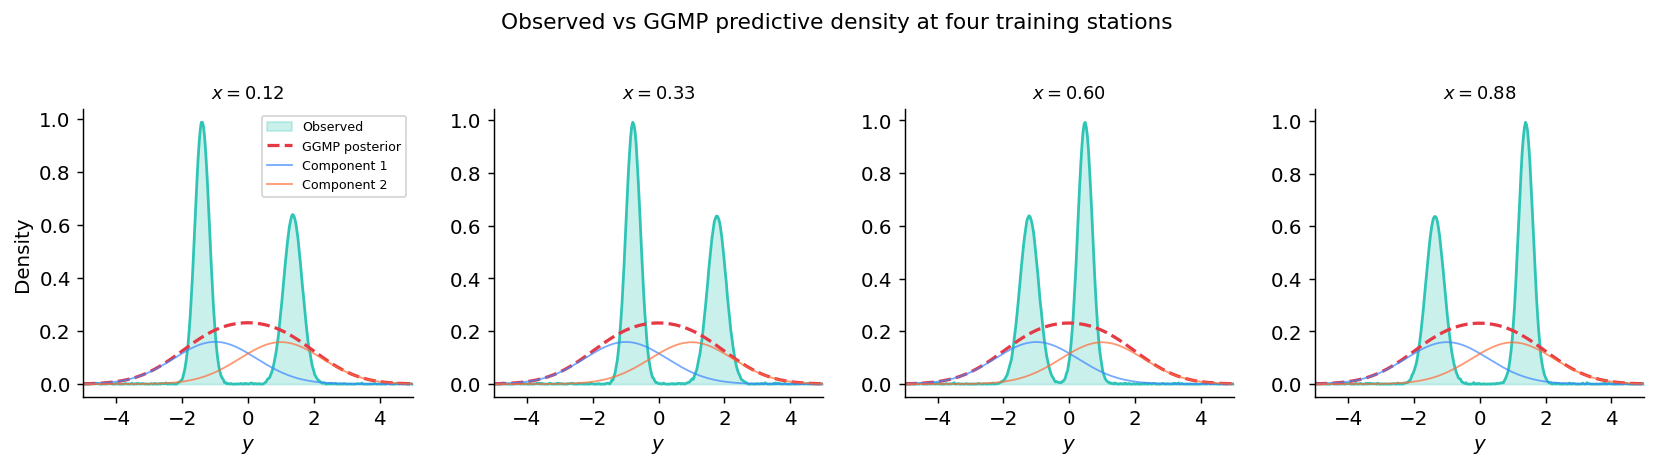

In [12]:
# ── Choose 4 representative stations ─────────────────────────────────────────
station_ids = [1, 4, 8, 12]
x_sel = x_train[station_ids]        # (4, 1)

# GP posteriors at the selected stations
comp_means_sel = np.stack(
    [g.gps[k].posterior_mean(x_sel)["m(x)"] for k in range(K)], axis=0
)  # (K, 4)
comp_vars_sel = np.stack(
    [g.gps[k].posterior_covariance(x_sel, variance_only=True)["v(x)"] for k in range(K)], axis=0
)  # (K, 4)
comp_stds_sel = np.sqrt(np.maximum(comp_vars_sel + mean_noise[:, None], 0))

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5), sharey=False)

for col, (sid, ax) in enumerate(zip(station_ids, axes)):
    xi = float(x_train[sid, 0])
    dom, dens = y_data[sid]
    _, p_obs, dx_obs = ggmp_module._normalize_pdf(dom, dens)

    # Observed (true) density
    ax.fill_between(dom, p_obs, alpha=0.25, color=GREEN, label="Observed")
    ax.plot(dom, p_obs, color=GREEN, lw=1.5)

    # GGMP predictive density
    pred = np.zeros(len(y_grid))
    for k in range(K):
        pred += w_norm[k] * norm.pdf(
            y_grid,
            loc=float(comp_means_sel[k, col]),
            scale=float(comp_stds_sel[k, col]),
        )
    ax.plot(y_grid, pred, "--", color=RED, lw=1.8, label="GGMP posterior")

    # Individual component predictive curves
    for k, c in enumerate(colors_k):
        comp_curve = norm.pdf(
            y_grid,
            loc=float(comp_means_sel[k, col]),
            scale=float(comp_stds_sel[k, col]),
        )
        ax.plot(y_grid, w_norm[k] * comp_curve, color=c, lw=1.0,
                alpha=0.7, label=f"Component {k+1}" if col == 0 else None)

    ax.set_title(f"$x = {xi:.2f}$", fontsize=10)
    ax.set_xlabel("$y$")
    if col == 0:
        ax.set_ylabel("Density")
        ax.legend(fontsize=7)
    ax.set_xlim(dom[0], dom[-1])

fig.suptitle("Observed vs GGMP predictive density at four training stations",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Prediction at unseen locations

Finally we pick three **unseen** test locations and show the model's predictive distribution there — purely generalization, not interpolation from training data.

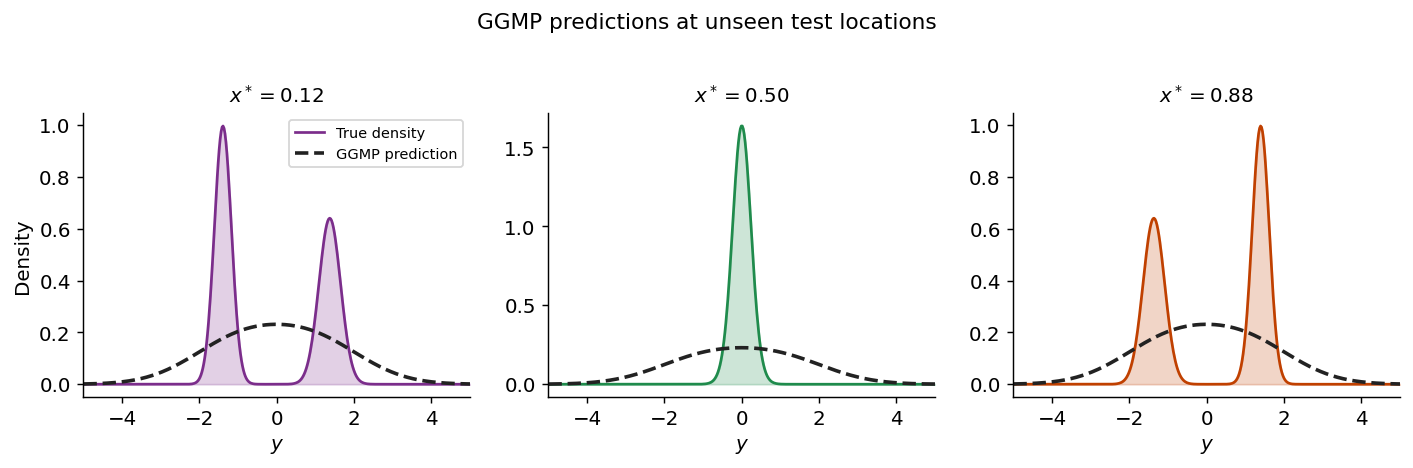

In [13]:
x_test = np.array([[0.12], [0.50], [0.88]])
labels = [f"$x^* = {xi:.2f}$" for xi in x_test[:, 0]]

comp_means_test = np.stack(
    [g.gps[k].posterior_mean(x_test)["m(x)"] for k in range(K)], axis=0
)
comp_vars_test = np.stack(
    [g.gps[k].posterior_covariance(x_test, variance_only=True)["v(x)"] for k in range(K)], axis=0
)
comp_stds_test = np.sqrt(np.maximum(comp_vars_test + mean_noise[:, None], 0))

# True predictive densities at the test locations
def true_density(xi, y):
    return (w_true[0] * norm.pdf(y, float(mu1(xi)), sigma1) +
            w_true[1] * norm.pdf(y, float(mu2(xi)), sigma2))

colors_test = ["#7B2D8B", "#1F8B4C", "#C04000"]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

for col, (xi, ax, lbl, c) in enumerate(
        zip(x_test[:, 0], axes, labels, colors_test)):

    # True density
    true_dens = true_density(xi, y_grid)
    true_dens /= np.trapezoid(true_dens, y_grid) + 1e-300
    ax.fill_between(y_grid, true_dens, alpha=0.22, color=c)
    ax.plot(y_grid, true_dens, color=c, lw=1.5, label="True density")

    # GGMP predictive density
    pred = np.zeros(len(y_grid))
    for k in range(K):
        pred += w_norm[k] * norm.pdf(
            y_grid,
            loc=float(comp_means_test[k, col]),
            scale=float(comp_stds_test[k, col]),
        )
    ax.plot(y_grid, pred, "--", color="#222222", lw=2.0, label="GGMP prediction")

    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel("$y$")
    if col == 0:
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
    ax.set_xlim(y_grid[0], y_grid[-1])

fig.suptitle("GGMP predictions at unseen test locations",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Summary

| Step | Code |
|---|---|
| Define hyperparameter bounds | `hyperparameters(weights, w_bounds, hps, hps_bounds)` |
| Construct model | `GGMP(x_data, y_data, hps_obj=hps_obj, likelihood_terms=K)` |
| Seed likelihoods | `g.initLikelihoods()` |
| Build component GPs | `g.initGPs()` |
| Train (hyperparams + weights) | `g.train(method="local", max_iter=200)` |
| Mixture mean | `g.posterior_mean(x_pred)` |
| Mixture variance | `g.posterior_variance(x_pred)` |
| Full predictive density | evaluate `∑ wₖ N(y \| μₖ(x*), νₖ(x*) + s̄²ₖ)` per prediction point |

The model correctly recovers the bimodal structure of the data and produces calibrated predictive distributions that smoothly interpolate between training stations.